##### Feladat

Az alábbi kéttámaszú tartót a berajzolt megoszló erőrendszer terheli.

Feladatok:

a) Rajzolja fel az $\eta$ paraméter függvényében a reakciók nagyságának arányát: $\frac{\vert F_B \vert }{\vert F_A \vert} = f(\eta)$!

b) Mekkora legyen $\eta$, hogy $\frac{\vert F_B \vert }{\vert F_A \vert} = 2$?

<img src="img/01.jpg" alt="Feladat" width=350px>

##### Csomagok importálása

In [1]:
import numpy as np # Numerikus számítások
import matplotlib.pyplot as plt # Ábrázolás
plt.rcParams['mathtext.fontset'] = 'cm' # Betűtípus az ábrákon
plt.rcParams['font.family'] = 'serif' # Betűtípus az ábrákon
plt.rcParams['font.serif'] = ['cmr10'] # Betűtípus az ábrákon
plt.rcParams['axes.formatter.use_mathtext'] = True # Betűtípus az ábrákon
plt.rcParams['axes.unicode_minus'] = False # Betűtípus az ábrákon
from IPython.display import display, Math, Latex # Szép kimenet Jupyter notebookban
import sympy as sp # Szimbólikus számítások
from sympy import latex # Szép kimenet Jupyter notebookban
sp.init_printing() # Szép kimenet Jupyter notebookban

##### Adatok

In [2]:
L = sp.Symbol('L', nonzero=True) # L nem lehet zérus
eta = sp.symbols('η')

##### Szabadtest ábra

<img src="img/02.jpg" alt="Feladat" width=400px>

##### A reakciók

In [3]:
A_x, A_y, B_y, x = sp.symbols('A_x, A_y, B_y, x')

##### A megolszló helyettesítése

In [4]:
# Háromszög
display(Latex('Háromszög:'))
F_p1 = (L/2) * (eta*L) / 2
display(Math(rf'F_{{p1}} = {latex(F_p1)}'))

x_s1 = sp.Rational(2,3) * (L/2)
display(Math(rf'x_{{s1}} = {latex(x_s1)}'))

# Téglalap
display(Latex('Téglalap:'))
F_p2 = (L/2) * (eta*L)
display(Math(rf'F_{{p2}} = {latex(F_p2)}'))

x_s2 = sp.Rational(3,2) * (L/2)
display(Math(rf'x_{{s2}} = {latex(x_s2)}'))

# Félkör
display(Latex('Félkör:'))
F_p3 = ((L/2)**2*sp.pi/4) * sp.Rational(1,2)
display(Math(rf'F_{{p3}} = {latex(F_p3)}'))

x_s3 = sp.Rational(3,2)*(L/2)
display(Math(rf'x_{{s3}} = {latex(x_s3)}'))

# Megjegyzés: az sp.Rational(számláló, nevező) parancsot használva nem float-ként kezeli a számokat a program, hanem tényleges tört változóként.

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Latex object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

##### Egyensúlyi egyenletek

In [5]:
# x irányú erő egyensúly
eq1 = A_x
display(Math(rf'\sum F_x = 0 \quad \longrightarrow \quad {latex(eq1)} = 0'))

# y irányú erő egyensúly
eq2 = A_y - F_p1  - F_p2 - F_p3 + B_y
display(Math(rf'\sum F_y = 0 \quad \longrightarrow \quad {latex(eq2)} = 0'))

# z irányú nyomatéki egyensúly
eq3 = -F_p1*x_s1 - F_p2*x_s2 - F_p3*x_s3 + B_y*L 
display(Math(rf'\sum M_A = 0 \quad \longrightarrow \quad {latex(eq3)} = 0'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

##### Egyensúlyi egyenletek megoldása

In [6]:
sol = sp.solve([eq1, eq2, eq3], [A_x, A_y, B_y])

A_xsol = sol[A_x]
display(Math(rf'A_x = {latex(A_xsol)} ~ \mathrm{{N}}'))

A_ysol = sol[A_y]
display(Math(rf'A_y = {latex(A_ysol)}'))

B_ysol = sol[B_y]
display(Math(rf'B_y = {latex(B_ysol)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [7]:
F_B = B_ysol
F_A = A_ysol

##### A keresett függvény

In [8]:
f = sp.simplify(sp.Abs(F_B) / sp.Abs(F_A))
display(Math(rf'f = {latex(f)}'))

<IPython.core.display.Math object>

##### A függvény ábrázolása

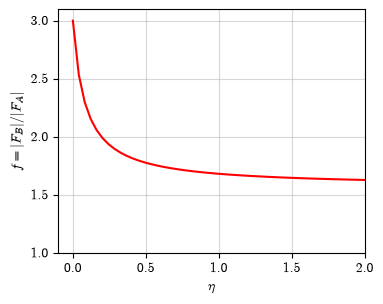

In [9]:
f_numeric = sp.lambdify(eta, f, 'numpy')

eta_vals = np.linspace(0, 2)
f_vals = f_numeric(eta_vals)

plt.figure(figsize=(10/2.54, 8/2.54))
plt.plot(eta_vals, f_vals, color='red')
plt.xlabel(r'$\eta$')
plt.ylabel(r'$f = \vert F_B \vert  / \vert F_A \vert$')
plt.xlim(-0.1, 2)
plt.ylim(1, 3.1)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig('eredmeny.pdf')